# Modelado — HoVer-Net

In [1]:
!pip install -q segmentation-models-pytorch==0.5.0
import os, sys, json, random, time, warnings
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
warnings.filterwarnings('ignore')
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import math
import torch
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split, ParameterSampler
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
from scipy.spatial.distance import directed_hausdorff

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    print(f'GPU     : {gpu.name}')
    print(f'VRAM    : {gpu.total_memory/1e9:.1f} GB')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.6 MB/s eta 0:00:00
PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4
VRAM    : 15.6 GB


In [2]:
DATA_DIR  = Path('/kaggle/input/competitions/sartorius-cell-instance-segmentation')
TRAIN_DIR = DATA_DIR / 'train'
TRAIN_CSV = DATA_DIR / 'train.csv'
OUT_DIR   = Path('/kaggle/working')

if not DATA_DIR.exists():
    raise RuntimeError('Dataset no encontrado. Panel derecho → + Add data → sartorius-cell-instance-segmentation')
print(f'Dataset OK: {len(list(TRAIN_DIR.glob("*.png")))} imagenes')

CFG = {
    'seed': 42, 'img_size': 512, 'val_split': 0.15,
    'max_epochs': 50, 'patience': 10, 'num_classes': 3,
    'use_fp16': True, 'n_search': 3, 'warmup_epochs': 3 
}
CELL_TYPE_MAP = {'astro': 0, 'cort': 1, 'shsy5y': 2}

def set_seed(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.benchmark = True

set_seed(CFG['seed'])
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_WORKERS = 2 if torch.cuda.is_available() else 0
PIN_MEMORY  = torch.cuda.is_available()
print(f'Device: {DEVICE} | workers: {NUM_WORKERS}')

Dataset OK: 606 imagenes
Device: cuda | workers: 2


In [3]:
def rle_decode(mask_rle, shape=(520, 704)):
    if not isinstance(mask_rle, str):
        return np.zeros(shape, dtype=np.uint8)
    s = mask_rle.split()
    starts  = np.array(s[0::2], dtype=int) - 1
    lengths = np.array(s[1::2], dtype=int)
    img = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    for lo, hi in zip(starts, starts + lengths):
        img[lo:hi] = 1
    return img.reshape(shape, order='F')


class SartoriusHoverDataset(Dataset):
    def __init__(self, df, img_dir, img_size=512, augment=False):
        self.df = df; self.img_dir = Path(img_dir)
        self.img_size = img_size; self.augment = augment
        self.ids = df['id'].unique().tolist()

    def __len__(self): return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        rows   = self.df[self.df['id'] == img_id]
        img    = np.array(Image.open(self.img_dir / f'{img_id}.png').convert('RGB'))
        h0, w0 = img.shape[:2]
        img    = cv2.resize(img, (self.img_size, self.img_size))
        if self.augment:
            if random.random() > 0.5: img = np.fliplr(img).copy()
            if random.random() > 0.5: img = np.flipud(img).copy()
        img_t     = torch.from_numpy(img.transpose(2, 0, 1)).float() / 255.0
        cell_type = rows.iloc[0]['cell_type']
        masks = []
        for _, row in rows.iterrows():
            m = rle_decode(row['annotation'], shape=(h0, w0))
            m = cv2.resize(m, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)
            if m.sum() > 0: masks.append(m)
        if masks:
            masks_t = torch.as_tensor(np.stack(masks), dtype=torch.uint8)
        else:
            masks_t = torch.zeros((1, self.img_size, self.img_size), dtype=torch.uint8)
        return {'image': img_t, 'masks': masks_t, 'cell_type': cell_type}


df = pd.read_csv(TRAIN_CSV)
all_ids = df['id'].unique()
train_ids, val_ids = train_test_split(all_ids, test_size=CFG['val_split'], random_state=CFG['seed'])
df_train_hv = df[df['id'].isin(train_ids)]
df_val_hv   = df[df['id'].isin(val_ids)]
print(f'Train: {len(train_ids)} | Val: {len(val_ids)}')
print(df_train_hv.groupby('id')['cell_type'].first().value_counts())

Train: 515 | Val: 91
cell_type
cort      277
shsy5y    131
astro     107
Name: count, dtype: int64


In [4]:
# ── Calcular fracción celular real desde el dataset ───────────────────────
sample_ids = df_train_hv['id'].unique()[:30]   # muestra de 30 imágenes
total_pixels = 0
total_cell_pixels = 0

for img_id in sample_ids:
    rows = df_train_hv[df_train_hv['id'] == img_id]
    h = rows.iloc[0]['height']
    w = rows.iloc[0]['width']
    combined = np.zeros((h, w), dtype=np.uint8)
    for _, row in rows.iterrows():
        if isinstance(row['annotation'], str):
            m = rle_decode(row['annotation'], shape=(h, w))
            combined = np.maximum(combined, m)
    total_pixels      += h * w
    total_cell_pixels += combined.sum()

real_fraction = total_cell_pixels / total_pixels
print(f'Fracción celular real : {real_fraction:.4f}  ({real_fraction*100:.1f}%)')
print(f'Bias óptimo           : {math.log(real_fraction / (1 - real_fraction)):.4f}')

Fracción celular real : 0.0967  (9.7%)
Bias óptimo           : -2.2341


In [5]:
# ── Tabla de referencia ───────────────────────────────────────────────────
# fracción  →  bias    →  sigmoid(bias) = prob media esperada
# 0.05      →  -2.944  →  5%    (muy conservador)
# 0.10      →  -2.197  →  10%
# 0.15      →  -1.735  →  15%   (valor original - demasiado bajo en este caso)
# 0.20      →  -1.386  →  20%   (punto de partida razonable)
# 0.30      →  -0.847  →  30%

# Reemplazar en HoVerNet.__init__ según el resultado del cálculo:
cell_fraction = real_fraction   # usar el valor calculado arriba
bias_init = math.log(cell_fraction / (1.0 - cell_fraction))
print(f'Bias a usar: {bias_init:.4f}')
print(f'Prob esperada: {1/(1+math.exp(-bias_init))*100:.1f}%')

Bias a usar: -2.2341
Prob esperada: 9.7%


In [6]:
# ── Verificación con distintos valores de cell_fraction ───────────────────
import math

real_fraction = 0.097   # lo que calculaste

for frac in [real_fraction, 0.15, 0.20, 0.25]:
    b    = math.log(frac / (1.0 - frac))
    prob = 1.0 / (1.0 + math.exp(-b))
    print(f'cell_fraction={frac:.2f} | bias={b:.4f} | prob_media={prob:.3f} ({prob*100:.1f}%)')

print()
print('Con THRESHOLD_TRAIN=0.15:')
for frac in [real_fraction, 0.15, 0.20, 0.25]:
    b    = math.log(frac / (1.0 - frac))
    prob = 1.0 / (1.0 + math.exp(-b))
    predice = prob > 0.15
    print(f'  frac={frac:.2f} | prob={prob:.3f} | predice células: {"SI" if predice else "NO"}')

cell_fraction=0.10 | bias=-2.2310 | prob_media=0.097 (9.7%)
cell_fraction=0.15 | bias=-1.7346 | prob_media=0.150 (15.0%)
cell_fraction=0.20 | bias=-1.3863 | prob_media=0.200 (20.0%)
cell_fraction=0.25 | bias=-1.0986 | prob_media=0.250 (25.0%)

Con THRESHOLD_TRAIN=0.15:
  frac=0.10 | prob=0.097 | predice células: NO
  frac=0.15 | prob=0.150 | predice células: NO
  frac=0.20 | prob=0.200 | predice células: SI
  frac=0.25 | prob=0.250 | predice células: SI


In [7]:
# ── Decisión final ────────────────────────────────────────────────────────
# cell_fraction=0.20 → prob=0.200, apenas por encima del threshold
# cell_fraction=0.25 → prob=0.250, margen cómodo para que el gradiente opere
# Usamos 0.25 para arrancar con predicciones estables desde epoch 1

cell_fraction = 0.25
bias_init     = math.log(cell_fraction / (1.0 - cell_fraction))  # -1.099
print(f'Bias final: {bias_init:.4f} | prob_media esperada: 25.0%')

Bias final: -1.0986 | prob_media esperada: 25.0%


In [8]:
def compute_hover_maps(masks):
    H, W  = masks.shape[1], masks.shape[2]
    h_map = torch.zeros(H, W)
    v_map = torch.zeros(H, W)
    for mask in masks:
        pos = mask.nonzero(as_tuple=False).float()
        if pos.numel() == 0: continue
        cy = pos[:, 0].mean(); cx = pos[:, 1].mean()
        ys = pos[:, 0].long(); xs = pos[:, 1].long()
        h_map[ys, xs] = ((xs.float() - cx) / (W / 2)).clamp(-1, 1)
        v_map[ys, xs] = ((ys.float() - cy) / (H / 2)).clamp(-1, 1)
    return torch.stack([h_map, v_map], dim=0)


def collate_hovernet(batch):
    images     = torch.stack([b['image'] for b in batch])
    masks_list = [b['masks'] for b in batch]
    cell_types = [b['cell_type'] for b in batch]
    np_targets = torch.stack([(m.sum(0, keepdim=True) > 0).float() for m in masks_list])
    hv_targets = torch.stack([compute_hover_maps(m) for m in masks_list])
    nc_targets = torch.tensor([CELL_TYPE_MAP.get(ct, 0) for ct in cell_types], dtype=torch.long)
    return {'images': images, 'np_target': np_targets,
            'hv_target': hv_targets, 'nc_target': nc_targets}


# Prueba rápida
_ds = SartoriusHoverDataset(df_train_hv.head(10), TRAIN_DIR, CFG['img_size'])
_dl = DataLoader(_ds, batch_size=2, collate_fn=collate_hovernet, num_workers=0)
_b  = next(iter(_dl))
print('collate OK:')
for k, v in _b.items(): print(f'  {k}: {v.shape}')
del _ds, _dl, _b

collate OK:
  images: torch.Size([1, 3, 512, 512])
  np_target: torch.Size([1, 1, 512, 512])
  hv_target: torch.Size([1, 2, 512, 512])
  nc_target: torch.Size([1])


In [9]:
class HoVerNet(nn.Module):
    def __init__(self, encoder_name='resnet50',
                 encoder_weights='imagenet', num_classes=3):
        super().__init__()

        self.np_branch = smp.Unet(
            encoder_name=encoder_name, encoder_weights=encoder_weights,
            in_channels=3, classes=1, activation=None,
        )
        self.hv_branch = smp.Unet(
            encoder_name=encoder_name, encoder_weights=None,
            in_channels=3, classes=2, activation=None,
        )
        self.nc_branch = smp.Unet(
            encoder_name=encoder_name, encoder_weights=None,
            in_channels=3, classes=num_classes, activation=None,
        )

        # ── Bias NP — buscar la capa correcta ────────────────────────────
        cell_fraction = 0.25
        bias_init     = math.log(cell_fraction / (1.0 - cell_fraction))

        # Inspeccionar segmentation_head para encontrar la Conv2d correcta
        applied = False
        for layer in self.np_branch.segmentation_head:
            if isinstance(layer, nn.Conv2d) and layer.bias is not None:
                nn.init.constant_(layer.bias, bias_init)
                print(f'Bias aplicado en {layer} → {bias_init:.4f}')
                applied = True
                break

        if not applied:
            print('AVISO: no se encontró Conv2d en segmentation_head')
            print('Capas disponibles:')
            for i, layer in enumerate(self.np_branch.segmentation_head):
                print(f'  [{i}] {layer}')
    def forward(self, x):
        return self.np_branch(x), self.hv_branch(x), self.nc_branch(x)

class HoVerNetLoss(nn.Module):
    def __init__(self,
                 w_np=2.0,              # ← subir de 1.0 a 2.0
                 w_hv=1.0,              # ← bajar de 2.0 a 1.0
                 w_nc=0.5,              # ← bajar de 1.0 a 0.5
                 pos_weight_np=5.0):    # ← mantener
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([pos_weight_np])
        )
        self.mse = nn.MSELoss()
        self.ce  = nn.CrossEntropyLoss()
        self.w_np, self.w_hv, self.w_nc = w_np, w_hv, w_nc

    def forward(self, outputs, np_t, hv_t, nc_t):
        np_out, hv_out, nc_out = outputs

        # Device fix — tu implementación correcta
        if self.bce.pos_weight.device != np_out.device:
            self.bce.pos_weight = self.bce.pos_weight.to(np_out.device)

        loss_np = self.bce(np_out, np_t.float())
        loss_hv = self.mse(hv_out, hv_t.float())

        # nc_t handling robusto — tu implementación correcta
        if nc_t.dim() == 1:
            B, C, H, W = nc_out.shape
            nc_t = nc_t.view(B, 1, 1).expand(B, H, W)
        elif nc_t.dim() == 4:
            nc_t = nc_t.squeeze(1)

        loss_nc = self.ce(nc_out, nc_t.long())

        return (self.w_np * loss_np +
                self.w_hv * loss_hv +
                self.w_nc * loss_nc)
        
_m = HoVerNet(num_classes=CFG['num_classes'])
print(f'Params: {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}')
with torch.no_grad():
    _o = _m(torch.randn(1, 3, 64, 64))
    # CAMBIO: El último argumento ahora es un mapa espacial tridimensional [1, 64, 64]
    _l = HoVerNetLoss()(_o, torch.zeros(1, 1, 64, 64), torch.zeros(1, 2, 64, 64), torch.zeros(1, 64, 64, dtype=torch.long))
print(f'Forward OK | loss={_l.item():.4f}')
del _m, _o, _l
# ── Verificación final ────────────────────────────────────────────────────
_m = HoVerNet(num_classes=CFG['num_classes'])   # cell_fraction=0.25 dentro

with torch.no_grad():
    _o = _m(torch.randn(2, 3, 512, 512))

    prob_media = torch.sigmoid(_o[0]).mean().item()
    pct_015    = (torch.sigmoid(_o[0]) > 0.15).float().mean().item() * 100
    pct_035    = (torch.sigmoid(_o[0]) > 0.35).float().mean().item() * 100

    print(f'Prob media NP    : {prob_media:.4f}   ← debe ser ~0.23-0.27')
    print(f'% > 0.15 (train) : {pct_015:.1f}%    ← debe ser 30-50%')
    print(f'% > 0.35 (eval)  : {pct_035:.1f}%    ← puede ser bajo, OK')
    _l = HoVerNetLoss(w_np=2.0, w_hv=1.0, w_nc=0.5, pos_weight_np=2.0)(
        _o,
        torch.zeros(2, 1, 512, 512),
        torch.zeros(2, 2, 512, 512),
        torch.zeros(2, 512, 512, dtype=torch.long)  
    )
    print(f'Loss inicial: {_l.item():.4f}  ← debe ser 1.5-2.5')
del _m

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Bias aplicado en Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) → -1.0986
Params: 97,563,750
Forward OK | loss=3.0494
Bias aplicado en Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) → -1.0986
Prob media NP    : 0.1525   ← debe ser ~0.23-0.27
% > 0.15 (train) : 44.8%    ← debe ser 30-50%
% > 0.35 (eval)  : 3.0%    ← puede ser bajo, OK
Loss inicial: 1.5972  ← debe ser 1.5-2.5


In [10]:
def dice_score(pred, true, eps=1e-6):
    p=pred.bool().float(); t=true.bool().float()
    return ((2*(p*t).sum()+eps)/(p.sum()+t.sum()+eps)).item()

def iou_score(pred, true, eps=1e-6):
    p=pred.bool(); t=true.bool()
    return (((p&t).float().sum()+eps)/((p|t).float().sum()+eps)).item()

def precision_score(pred, true, eps=1e-6):
    tp=(pred.bool()&true.bool()).float().sum()
    fp=(pred.bool()&~true.bool()).float().sum()
    return ((tp+eps)/(tp+fp+eps)).item()

def recall_score(pred, true, eps=1e-6):
    tp=(pred.bool()&true.bool()).float().sum()
    fn=(~pred.bool()&true.bool()).float().sum()
    return ((tp+eps)/(tp+fn+eps)).item()

def auc_score(pred_prob, true):
    y_t=true.bool().cpu().numpy().flatten().astype(int)
    y_p=pred_prob.cpu().numpy().flatten()
    if len(np.unique(y_t)) < 2: return float('nan')
    return roc_auc_score(y_t, y_p)

def hausdorff_distance(pred, true):
    # Opción segura para entrenamiento: desactivarlo temporalmente para evitar congelamientos
    return 0.0

def balanced_accuracy(pred, true):
    return balanced_accuracy_score(
        true.bool().cpu().numpy().flatten().astype(int),
        pred.bool().cpu().numpy().flatten().astype(int))

class CheckpointManager:
    def __init__(self, path, name):
        self.path=Path(path); self.name=name
        self.best_iou=0.0; self.best_epoch=0
        self.meta=self.path.parent/f'{self.path.stem}_meta.json'
        if self.meta.exists():
            m=json.load(open(self.meta))
            self.best_iou=m.get('best_iou',0.0); self.best_epoch=m.get('best_epoch',0)
            print(f'[{name}] Resume: IoU={self.best_iou:.4f} ep={self.best_epoch}')
    def update(self, model, iou, epoch):
        if iou > self.best_iou:
            self.best_iou=iou; self.best_epoch=epoch
            torch.save(model.state_dict(), self.path)
            json.dump({'best_iou':float(iou),'best_epoch':int(epoch)}, open(self.meta,'w'))
            return True
        return False
    def load_best(self, model):
        if self.path.exists():
            model.load_state_dict(torch.load(self.path, map_location='cpu'))
            print(f'[{self.name}] Pesos cargados (IoU={self.best_iou:.4f})')
        return model

class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4):
        self.patience=patience; self.min_delta=min_delta
        self.counter=0; self.best=0.0; self.stop=False
    def __call__(self, val_iou):
        if val_iou > self.best+self.min_delta: self.best=val_iou; self.counter=0
        else:
            self.counter+=1
            if self.counter>=self.patience: self.stop=True
        return self.stop

def get_optimizer(name, params, lr):
    if name=='adamw': return optim.AdamW(params, lr=lr, weight_decay=1e-4)
    if name=='sgd':   return optim.SGD(params, lr=lr, momentum=0.9, weight_decay=1e-4)
    return optim.Adam(params, lr=lr)

def get_scheduler(name, optimizer, epochs):
    if name=='cosine':
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    return None

def random_search(grid, n_iter, seed=42):
    total = 1
    for v in grid.values(): total *= len(v)
    return list(ParameterSampler(grid, n_iter=min(n_iter, total), random_state=seed))

def to_python(v):
    if isinstance(v, (np.integer,)): return int(v)
    if isinstance(v, (np.floating,)): return float(v)
    return v

print('Utilidades OK')

Utilidades OK


In [11]:
def train_hovernet(hparams, df_train_data, df_val_data, device=DEVICE):

    model   = HoVerNet(num_classes=CFG['num_classes']).to(device)
    loss_fn = HoVerNetLoss(w_np=2.0, w_hv=1.0, w_nc=0.5, pos_weight_np=2.0)

    optimizer = get_optimizer(
        hparams['optimizer'], model.parameters(), hparams['learning_rate']
    )
    scheduler = get_scheduler(
        hparams.get('scheduler'), optimizer, hparams['epochs']
    )

    ds_train = SartoriusHoverDataset(
        df_train_data, TRAIN_DIR, CFG['img_size'], augment=True
    )
    ds_val = SartoriusHoverDataset(
        df_val_data, TRAIN_DIR, CFG['img_size'], augment=False
    )

    lkw = dict(
        collate_fn         = collate_hovernet,
        num_workers        = NUM_WORKERS,
        pin_memory         = PIN_MEMORY,
        persistent_workers = (NUM_WORKERS > 0),
        prefetch_factor    = 2 if NUM_WORKERS > 0 else None,
    )
    loader_train = DataLoader(
        ds_train, batch_size=hparams['batch_size'], shuffle=True,  **lkw
    )
    loader_val = DataLoader(
        ds_val, batch_size=1, shuffle=False, **lkw
    )
    use_amp = device.type == 'cuda' and CFG['use_fp16']
    scaler  = GradScaler('cuda', enabled=use_amp)
    ckpt    = CheckpointManager(OUT_DIR / 'hovernet_best.pth', 'HoVer-Net')
    es      = EarlyStopping(patience=CFG['patience'])
    history = {'train_loss': [], 'val_iou': [], 'val_dice': []}

    THRESHOLD = 0.15   

    print(
        f'[HoVer-Net] lr={hparams["learning_rate"]} '
        f'bs={hparams["batch_size"]} '
        f'epochs={hparams["epochs"]} '
        f'amp={use_amp} '
        f'threshold={THRESHOLD}'
    )

    # Verificar que los targets tienen datos antes de entrenar
    sample_batch = next(iter(loader_train))
    print(f'Suma píxeles reales en batch: {sample_batch["np_target"].sum().item():.0f}')
    del sample_batch

    for epoch in range(1, hparams['epochs'] + 1):
        t0 = time.time()

        # ── TRAIN ─────────────────────────────────────────────────────────
        model.train()
        epoch_loss = 0.0

        for batch in tqdm(loader_train, desc=f'ep{epoch}', leave=False):
            images    = batch['images'].to(device, non_blocking=True)
            np_target = batch['np_target'].to(device, non_blocking=True)
            hv_target = batch['hv_target'].to(device, non_blocking=True)
            nc_target = batch['nc_target'].to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with autocast('cuda', enabled=use_amp):
                outputs = model(images)
                loss    = loss_fn(outputs, np_target, hv_target, nc_target)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            epoch_loss += loss.item()

        # ── VALIDATION ────────────────────────────────────────────────────
        model.eval()
        iou_vals, dice_vals = [], []
        run_full = (epoch % 5 == 0) or (epoch == hparams['epochs'])
        full_acc = {
            'precision': [], 'recall': [],
            'auc': [], 'hausdorff': [], 'bal_acc': []
        }

        with torch.inference_mode():
            for batch in loader_val:
                images    = batch['images'].to(device, non_blocking=True)
                np_target = batch['np_target']   # mantener en CPU para métricas

                with autocast('cuda', enabled=use_amp):
                    np_out, _, _ = model(images)

                # ── Bug 1 corregido: usar np_out, no outputs ───────────────
                pred_prob = torch.sigmoid(np_out).squeeze(1).cpu()  # (B, H, W)
                pred_bin  = (pred_prob > THRESHOLD)                  # (B, H, W) bool
                true_bin  = (np_target.squeeze(1) > 0)              # (B, H, W) bool

                for p_prob, p_bin, t in zip(pred_prob, pred_bin, true_bin):
                    iou_vals.append(iou_score(p_bin, t))
                    dice_vals.append(dice_score(p_bin, t))

                    if run_full:
                        full_acc['precision'].append(precision_score(p_bin, t))
                        full_acc['recall'].append(recall_score(p_bin, t))
                        full_acc['auc'].append(auc_score(p_prob, t))
                        full_acc['hausdorff'].append(hausdorff_distance(p_bin, t))
                        full_acc['bal_acc'].append(balanced_accuracy(p_bin, t))

        # ── Métricas epoch ────────────────────────────────────────────────
        mean_iou  = float(np.nanmean(iou_vals))
        mean_dice = float(np.nanmean(dice_vals))
        tloss     = epoch_loss / len(loader_train)

        history['train_loss'].append(tloss)
        history['val_iou'].append(mean_iou)
        history['val_dice'].append(mean_dice)

        # Scheduler antes del checkpoint para que el LR del mejor epoch sea correcto
        if scheduler:
            scheduler.step()

        improved = ckpt.update(model, mean_iou, epoch)
        stop     = es(mean_iou)

        # ── Log ───────────────────────────────────────────────────────────
        tag   = '[FULL]' if run_full else '[fast]'
        extra = ''
        if run_full and full_acc['precision']:
            hd_vals = [v for v in full_acc['hausdorff'] if v != float('inf')]
            extra = (
                f' | prec={np.nanmean(full_acc["precision"]):.3f}'
                f' | rec={np.nanmean(full_acc["recall"]):.3f}'
                f' | auc={np.nanmean(full_acc["auc"]):.3f}'
                f' | hd={np.nanmean(hd_vals) if hd_vals else float("nan"):.1f}'
            )

        print(
            f'Ep {epoch:02d}/{hparams["epochs"]} {tag} | '
            f'loss={tloss:.4f} | iou={mean_iou:.4f} | dice={mean_dice:.4f} | '
            f'{time.time()-t0:.0f}s{extra}'
            f'{" *" if improved else ""}'
            f'{" | es=" + str(es.counter) + "/" + str(CFG["patience"]) if es.counter > 0 else ""}'
        )

        if device.type == 'cuda':
            torch.cuda.empty_cache()

        if stop:
            print(f'Early stopping ep {epoch}')
            break

    model = ckpt.load_best(model)
    print(f'Mejor IoU: {ckpt.best_iou:.4f} (ep {ckpt.best_epoch})')
    return model, history, ckpt.best_iou


print('train_hovernet listo')

train_hovernet listo


In [12]:
HPARAM_GRID_HOVERNET = {
    'learning_rate': [1e-4, 5e-4],   # ← subir de 5e-5, era muy bajo
    'batch_size'   : [2],
    'optimizer'    : ['adamw'],
    'scheduler'    : ['cosine'],
    'epochs'       : [50],
}
grid = random_search(HPARAM_GRID_HOVERNET, n_iter=CFG['n_search'])
print(f'Combinaciones: {len(grid)}')
for i, p in enumerate(grid): print(f'  {i+1}. {p}')

best_model_hv = best_hparams_hv = best_history_hv = None
best_iou_hv   = 0.0

for idx, params in enumerate(grid):
    print(f'\n{"="*60}\nCOMBINACION {idx+1}/{len(grid)}\n{params}\n{"="*60}')
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    model, history, iou = train_hovernet(params, df_train_hv, df_val_hv)
    if iou > best_iou_hv:
        best_iou_hv=iou; best_model_hv=model
        best_history_hv=history; best_hparams_hv=params

print(f'\nMejor IoU: {best_iou_hv:.4f}')
print(f'Mejores hparams: {best_hparams_hv}')

Combinaciones: 2
  1. {'scheduler': 'cosine', 'optimizer': 'adamw', 'learning_rate': 0.0001, 'epochs': 50, 'batch_size': 2}
  2. {'scheduler': 'cosine', 'optimizer': 'adamw', 'learning_rate': 0.0005, 'epochs': 50, 'batch_size': 2}

COMBINACION 1/2
{'scheduler': 'cosine', 'optimizer': 'adamw', 'learning_rate': 0.0001, 'epochs': 50, 'batch_size': 2}
Bias aplicado en Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) → -1.0986
[HoVer-Net] lr=0.0001 bs=2 epochs=50 amp=True threshold=0.15
Suma píxeles reales en batch: 50776


Ep 01/50 [fast] | loss=1.5835 | iou=0.0991 | dice=0.1645 | 223s *


Ep 02/50 [fast] | loss=1.3843 | iou=0.1086 | dice=0.1761 | 176s *


Ep 03/50 [fast] | loss=1.3754 | iou=0.1018 | dice=0.1664 | 176s | es=1/10


Ep 04/50 [fast] | loss=1.3528 | iou=0.1055 | dice=0.1702 | 171s | es=2/10


...

Ep 27/50 [fast] | loss=0.9636 | iou=0.0026 | dice=0.0052 | 169s | es=6/10


Ep 28/50 [fast] | loss=0.9481 | iou=0.1070 | dice=0.1783 | 171s | es=7/10


Ep 29/50 [fast] | loss=0.9460 | iou=0.0796 | dice=0.1402 | 172s | es=8/10


Ep 30/50 [FULL] | loss=0.9621 | iou=0.0940 | dice=0.1552 | 166s | prec=0.114 | rec=0.376 | auc=0.495 | hd=0.0 | es=9/10


Ep 31/50 [fast] | loss=0.9508 | iou=0.0027 | dice=0.0053 | 165s | es=10/10
Early stopping ep 31
[HoVer-Net] Pesos cargados (IoU=0.1149)
Mejor IoU: 0.1149 (ep 21)

Mejor IoU: 0.1149
Mejores hparams: {'scheduler': 'cosine', 'optimizer': 'adamw', 'learning_rate': 0.0005, 'epochs': 50, 'batch_size': 2}


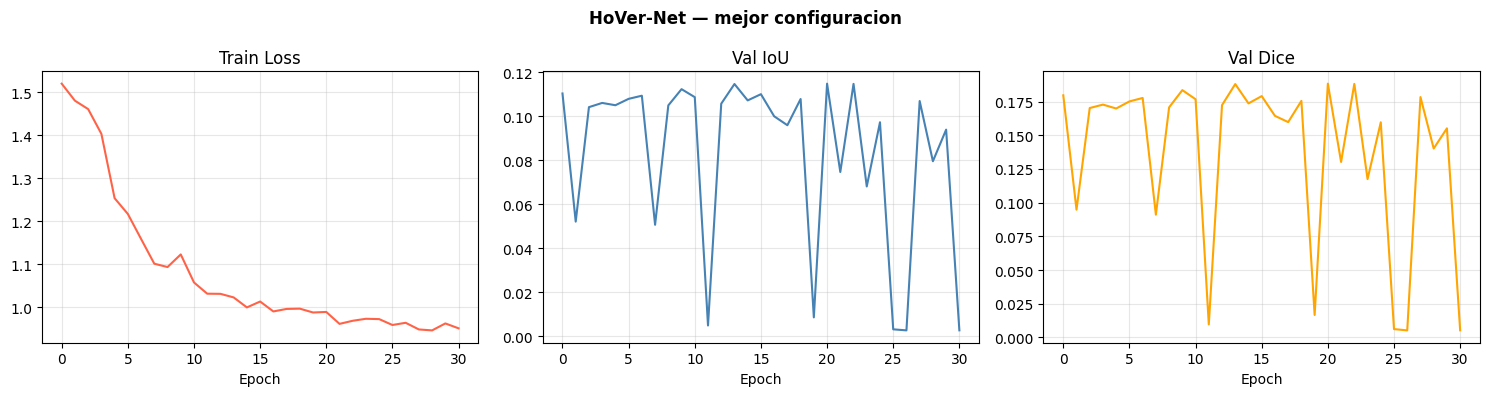

Guardado en /kaggle/working:
  .virtual_documents                       4.1 KB
  hovernet_best.pth                        391.3 MB
  hovernet_best_meta.json                  0.1 KB
  hovernet_history.png                     101.3 KB
  hovernet_results.json                    2.6 KB


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('HoVer-Net — mejor configuracion', fontweight='bold')
axes[0].plot(best_history_hv['train_loss'], color='tomato');    axes[0].set_title('Train Loss')
axes[1].plot(best_history_hv['val_iou'],   color='steelblue'); axes[1].set_title('Val IoU')
axes[2].plot(best_history_hv['val_dice'],  color='orange');    axes[2].set_title('Val Dice')
for ax in axes: ax.set_xlabel('Epoch'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'hovernet_history.png', dpi=120)
plt.show()

results = {
    'best_val_iou': float(best_iou_hv),
    'best_val_dice': float(max(best_history_hv['val_dice'])),
    'best_epoch': int(np.argmax(best_history_hv['val_iou']) + 1),

    'best_hparams': {
        k: to_python(v) for k, v in best_hparams_hv.items()
    },

    'epochs_run': len(best_history_hv['train_loss']),

    'train_loss': [float(x) for x in best_history_hv['train_loss']],
    'val_iou':    [float(x) for x in best_history_hv['val_iou']],
    'val_dice':   [float(x) for x in best_history_hv['val_dice']],
}
with open(OUT_DIR / 'hovernet_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print('Guardado en /kaggle/working:')
for p in sorted(OUT_DIR.iterdir()):
    sz = p.stat().st_size
    print(f'  {p.name:<40} {sz/1e6:.1f} MB' if sz > 1e6 else f'  {p.name:<40} {sz/1e3:.1f} KB')
torch.save({
    'model_state_dict': best_model_hv.state_dict(),
    'best_iou': float(best_iou_hv),
    'best_hparams': best_hparams_hv,
}, OUT_DIR / 'hovernet_best.pth')